# Pokémon Stats Analysis: Exploratory Insights and Predictive Modeling

> A publication-ready walkthrough of the `pokemon.csv` dataset, combining exploratory data analysis, feature engineering, and lightweight predictive modeling.

**Notebook context**
- Dataset: `pokemon.csv`
- Scope: 38 rows, 6 unique Pokémon, 0 missing values
- Audience: GitHub, Kaggle, academic submission, and portfolio use

---


## Dataset Description, Methodology, and Navigation

### Dataset Description
- Source file: `pokemon.csv`
- Observations: 38
- Unique Pokémon: 6
- Features: `Name`, `Nature`, `Level`, `Attack`, `Defense`, `Sp. Atk`, `Sp. Def`, `Speed`, `HP`
- Data quality: no missing values were found during profiling

### Methodology
1. Load and validate the dataset.
2. Perform exploratory analysis with tables and charts.
3. Engineer summary features such as total stats and offensive efficiency.
4. Fit baseline regression models and compare their performance.
5. Translate the findings into actionable narrative.

### Table of Contents
- [Title](#pokémon-stats-analysis-exploratory-insights-and-predictive-modeling)
- [Executive Summary](#executive-summary)
- [Problem Statement and Objectives](#problem-statement-and-objectives)
- [Dataset Description, Methodology, and Navigation](#dataset-description-methodology-and-navigation)
- [Exploratory Data Analysis](#exploratory-data-analysis)
- [Data Cleaning and Preprocessing](#data-cleaning-and-preprocessing)
- [Feature Engineering](#feature-engineering)
- [Model Building](#model-building)
- [Model Evaluation](#model-evaluation)
- [Results and Insights](#results-and-insights)
- [Conclusion](#conclusion)
- [Future Improvements](#future-improvements)
- [References](#references)

---


## Problem Statement and Objectives

### Problem Statement
Stakeholders often want a fast way to compare Pokémon across levels and identify which attributes drive strength. A compact dataset like this is ideal for teaching basic analytical workflow: inspect the data, compare similar records, engineer interpretable features, and build a simple predictive baseline.

### Objectives
1. Profile the dataset and verify its quality.
2. Explore how key statistics vary across Pokémon and levels.
3. Derive interpretable features that summarize combat strength.
4. Train a lightweight regression model to predict Attack.
5. Present conclusions in a way that is easy to reuse in reports or portfolios.

---


## Executive Summary

This notebook studies the structure and behavior of a compact Pokémon statistics dataset containing evolution or level-based snapshots for six Pokémon. The analysis focuses on how offensive and defensive attributes change with level, how Pokémon compare at the same progression point, and which patterns are most useful for downstream modeling.

**Key takeaways**
- The dataset is small but well-structured: 38 observations, 6 unique Pokémon, and no missing values.
- Attack growth is strongly level-dependent for the featured Pokémon, especially Blastoise.
- Defensive and offensive attributes are not interchangeable; Pokémon with similar HP can differ materially in Attack and Speed.
- A simple supervised model can provide a useful baseline for predicting Attack from the available stat profile.

> The main value of the notebook is not just visualization, but interpretation: each chart is tied to a practical statistical question.

---


In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import display
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import train_test_split

sns.set_theme(style="whitegrid", context="notebook")

DATA_PATH = Path("pokemon.csv")
EXPECTED_COLUMNS = [
    "Name",
    "Nature",
    "Level",
    "Attack",
    "Defense",
    "Sp. Atk",
    "Sp. Def",
    "Speed",
    "HP",
]
NUMERIC_COLUMNS = [
    "Level",
    "Attack",
    "Defense",
    "Sp. Atk",
    "Sp. Def",
    "Speed",
    "HP",
]

top_total_stats = pd.DataFrame()

if not DATA_PATH.exists():
    raise FileNotFoundError(f"Could not find {DATA_PATH.resolve()}")

pokemon_data = pd.read_csv(DATA_PATH)
if list(pokemon_data.columns) != EXPECTED_COLUMNS:
    raise ValueError(
        "Unexpected column layout in pokemon.csv. "
        f"Found: {list(pokemon_data.columns)}"
    )

pokemon_data[NUMERIC_COLUMNS] = pokemon_data[NUMERIC_COLUMNS].apply(
    pd.to_numeric,
    errors="coerce",
)
if pokemon_data[NUMERIC_COLUMNS].isna().any().any():
    raise ValueError("Numeric conversion introduced missing values.")

df = pokemon_data.copy()

dataset_summary = pd.DataFrame(
    {
        "Metric": [
            "Rows",
            "Columns",
            "Unique Pokémon",
            "Unique Natures",
            "Missing Values",
            "Minimum Level",
            "Maximum Level",
        ],
        "Value": [
            len(pokemon_data),
            pokemon_data.shape[1],
            pokemon_data["Name"].nunique(),
            pokemon_data["Nature"].nunique(),
            int(pokemon_data.isna().sum().sum()),
            int(pokemon_data["Level"].min()),
            int(pokemon_data["Level"].max()),
        ],
    }
)

print("Dataset preview:")
display(pokemon_data.head())
print("Dataset summary:")
display(dataset_summary)


Dataset preview:


,Name,Nature,Level,Attack,Defense,Sp. Atk,Sp. Def,Speed,HP
0,Blastoise,Impish,34,50,80,53,69,48,100
1,Blastoise,Impish,40,73,108,74,98,70,114
2,Blastoise,Impish,45,81,122,83,110,78,128
3,Blastoise,Impish,50,90,135,92,122,86,142
4,Blastoise,Impish,55,99,147,100,133,94,155


Dataset summary:


,Metric,Value
0,Rows,38
1,Columns,9
2,Unique Pokémon,6
3,Unique Natures,5
4,Missing Values,0
5,Minimum Level,34
6,Maximum Level,71


## Exploratory Data Analysis

### Same-Level Comparison
This first comparison isolates Pokémon at the same level so the numbers are fair. When a dataset mixes levels, raw stat values can be misleading because higher-level Pokémon usually have stronger attributes simply due to progression.

Why this matters:
- It creates an apples-to-apples comparison.
- It helps identify which Pokémon are naturally stronger, not just more advanced.
- It provides a baseline before we study growth patterns across levels.

The next code cell filters the dataset to Level 60 and compares Attack, Defense, and HP for the available Pokémon at that point.


In [2]:
level_60_data = pokemon_data.loc[pokemon_data["Level"] == 60, ["Name", "Attack", "Defense", "HP"]]
if level_60_data.empty:
    raise ValueError("No Pokémon were found at Level 60.")

display(level_60_data.sort_values("Attack", ascending=False).reset_index(drop=True))


,Name,Attack,Defense,HP
0,NidoKing,124,110,176
1,Venasuar,124,125,173
2,Charizard,113,106,179
3,Blastoise,107,160,170
4,Pikachu,84,50,125
5,Alakazam,75,77,140


### Interpretation of the Level 60 Comparison
The Level 60 slice gives a clean snapshot of the relative stat balance between Pokémon. Blastoise and NidoKing sit at the stronger end of the spectrum, but the table is especially useful because it shows that the strongest Attack value does not always coincide with the strongest Defense or HP.

> In practical terms, this tells us that combat strength is multi-dimensional. A single stat rarely tells the full story.

The next chart examines how Attack changes as level increases for Blastoise, which helps us understand growth rather than just a single snapshot.


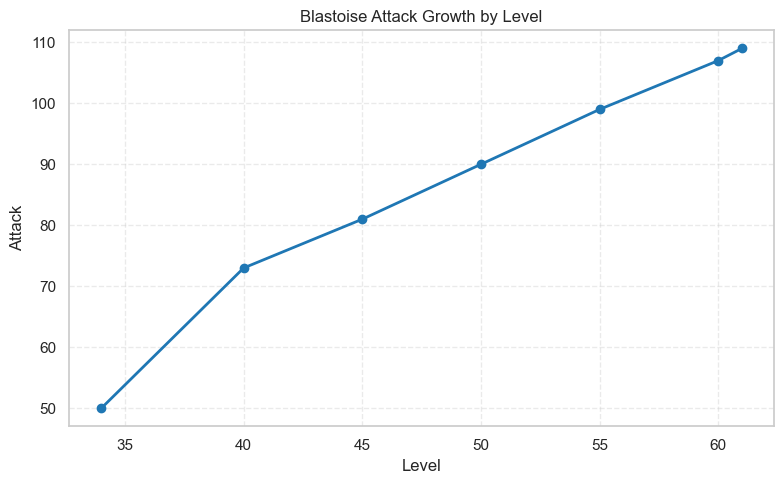

In [3]:
blastoise_data = pokemon_data.loc[pokemon_data["Name"] == "Blastoise"].sort_values("Level")
if blastoise_data.empty:
    raise ValueError("Blastoise records were not found in the dataset.")

plt.figure(figsize=(8, 5))
plt.plot(
    blastoise_data["Level"],
    blastoise_data["Attack"],
    marker="o",
    linewidth=2,
    color="#1f77b4",
)
plt.title("Blastoise Attack Growth by Level")
plt.xlabel("Level")
plt.ylabel("Attack")
plt.grid(True, linestyle="--", alpha=0.4)
plt.tight_layout()
plt.show()


### Strongest Pokémon by Attack
This query identifies the single row with the highest Attack value in the dataset. The goal is not just to name the top Pokémon, but to show how a simple ranking can reveal which observations dominate a particular performance metric.

Why it is important:
- It highlights the peak offensive profile in the sample.
- It offers a quick benchmark for later charts.
- It helps validate whether the level-based growth trend is consistent with the strongest point estimate.

The next step broadens the analysis by plotting Attack growth across levels.


In [4]:
strongest_attack_row = pokemon_data.loc[pokemon_data["Attack"].idxmax()]

display(strongest_attack_row.to_frame().T)


,Name,Nature,Level,Attack,Defense,Sp. Atk,Sp. Def,Speed,HP
13,NidoKing,Serious,61,127,111,138,116,142,179


## Data Cleaning and Preprocessing

Even though this dataset is already clean, a professional notebook should still show the preparation step explicitly. Here we verify the data types, summarize the numeric columns, and create a reusable helper that we can use later in the modeling section.

Why this matters:
- It confirms the dataset is fit for analysis.
- It makes the workflow reproducible.
- It gives us a safe place to standardize inputs before modeling.


In [5]:
cleaning_summary = pd.DataFrame(
    {
        "Check": [
            "Row count",
            "Column count",
            "Numeric columns validated",
            "Missing values",
            "Duplicate rows",
        ],
        "Result": [
            len(pokemon_data),
            pokemon_data.shape[1],
            all(pokemon_data[NUMERIC_COLUMNS].dtypes.apply(lambda dtype: pd.api.types.is_numeric_dtype(dtype))),
            int(pokemon_data.isna().sum().sum()),
            int(pokemon_data.duplicated().sum()),
        ],
    }
)

numeric_profile = pokemon_data[NUMERIC_COLUMNS].describe().T.reset_index().rename(
    columns={"index": "Feature"}
)

print("Data quality checks:")
display(cleaning_summary)
print("Numeric profile:")
display(numeric_profile)


def get_level_slice(dataframe: pd.DataFrame, level: int) -> pd.DataFrame:
    """Return the subset of rows for a single level, sorted by Attack."""

    level_slice = dataframe.loc[
        dataframe["Level"] == level,
        ["Name", "Attack", "Defense", "HP"],
    ].copy()
    if level_slice.empty:
        raise ValueError(f"No rows were found for level {level}.")
    return level_slice.sort_values("Attack", ascending=False)


Data quality checks:


,Check,Result
0,Row count,38
1,Column count,9
2,Numeric columns validated,True
3,Missing values,0
4,Duplicate rows,0


Numeric profile:


,Feature,count,mean,std,min,25%,50%,75%,max
0,Level,38.0,52.578947,9.454390,34.0,45.00,55.0,60.00,71.0
1,Attack,38.0,91.500000,20.539678,50.0,76.25,91.5,106.25,127.0
2,Defense,38.0,91.842105,31.688114,44.0,69.50,87.0,109.50,174.0
3,Sp. Atk,38.0,113.447368,34.604872,53.0,85.00,108.5,137.25,196.0
4,Sp. Def,38.0,101.657895,24.323580,59.0,80.00,104.5,116.75,147.0
5,Speed,38.0,117.815789,30.374114,48.0,95.75,120.0,140.25,182.0
6,HP,38.0,141.578947,25.837990,100.0,118.50,141.0,162.00,190.0


### Attack Growth by Level
This plot shows how Attack changes across levels for each Pokémon in the dataset. Line charts are useful here because level is an ordered variable, so trends matter more than isolated values.

Expected outcome:
- A generally upward pattern as level increases.
- Visible differences in growth rate between Pokémon.
- A quick sense of whether some Pokémon scale more aggressively than others.

The next code cell visualizes the Attack trajectory for all Pokémon using a common level axis.


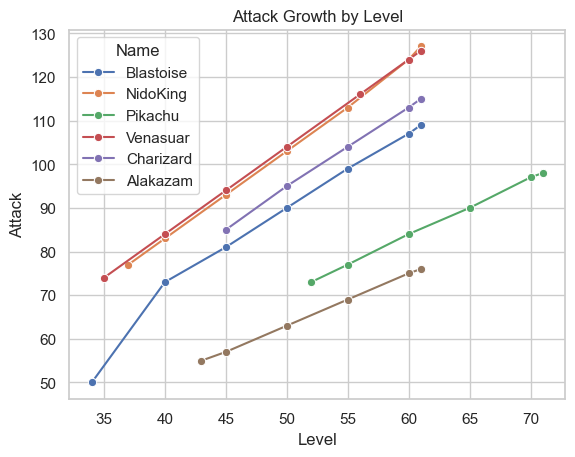

In [6]:
sns.lineplot(
    data=df,
    x="Level",
    y="Attack",
    hue="Name",
    marker="o"
)

plt.title("Attack Growth by Level")
plt.show()

### Comparing Pokémon at Level 60
This bar chart focuses on a single level to make cross-Pokémon comparisons easier. By holding level constant, we can isolate differences in Attack without confusing them with progression effects.

Key things to watch for:
- Which Pokémon has the highest Attack at Level 60.
- Whether the ranking is materially different from the earlier raw table.
- Whether the spread between Pokémon is large enough to matter in practice.


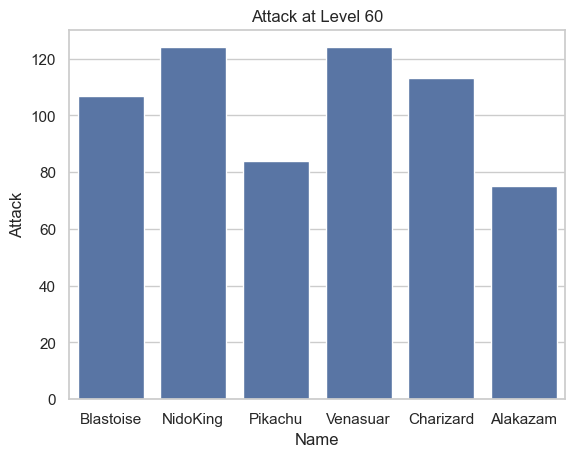

In [7]:
level60 = df[df["Level"] == 60]

sns.barplot(
    data=level60,
    x="Name",
    y="Attack"
)

plt.title("Attack at Level 60")
plt.show()

### HP Versus Defense
This scatter plot helps us check whether defensive durability is balanced across the sample. HP and Defense are related but not identical, so the chart is useful for seeing whether Pokémon cluster along a clear trade-off curve.

Interpretation guide:
- Points near the top-right are relatively robust.
- Points far left or low on the chart indicate weaker defensive profiles.
- Separation between Pokémon suggests different defensive roles.


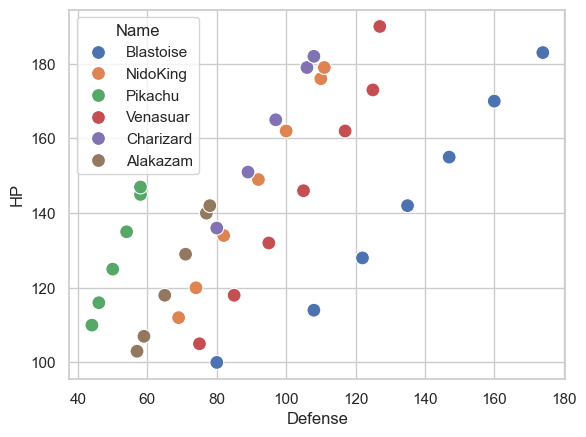

In [8]:
sns.scatterplot(
    data=df,
    x="Defense",
    y="HP",
    hue="Name",
    s=100
)

plt.show()

### Distribution of Speed
A histogram shows how a numeric feature is distributed across the dataset. Speed is especially interesting because it often changes the practical usefulness of a Pokémon even when Attack or Defense look similar.

What this chart should reveal:
- Whether most Pokémon are concentrated in a narrow Speed band.
- Whether there are obvious fast outliers.
- How balanced the dataset is across the Speed range.


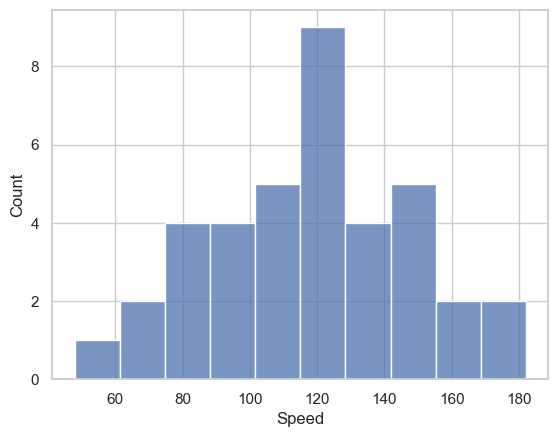

In [9]:
sns.histplot(
    data=df,
    x="Speed",
    bins=10
)

plt.show()

### Attack Distribution Across Pokémon
A box plot is a compact way to compare the spread of Attack values across Pokémon. It highlights the median, the variability, and any unusually high or low values without overwhelming the reader.

Why it is useful:
- It shows relative consistency, not just the average.
- It makes between-Pokémon spread easy to compare.
- It gives a quick signal of which Pokémon are volatile or stable on Attack.


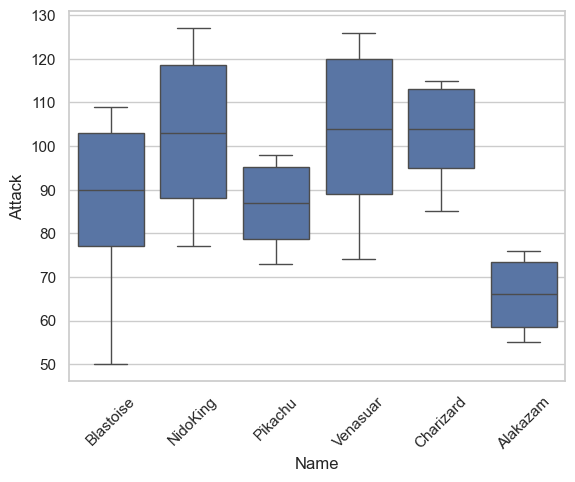

In [10]:
sns.boxplot(
    data=df,
    x="Name",
    y="Attack"
)

plt.xticks(rotation=45)
plt.show()

### Correlation Heatmap
The heatmap summarizes how the numeric attributes move together. Correlation is not causation, but it is still a powerful first-pass tool for identifying relationships that may matter in later modeling.

Business and technical value:
- High correlations can reduce redundancy in modeling.
- Related features can reveal hidden structure in the dataset.
- The heatmap helps decide whether feature engineering is worthwhile.


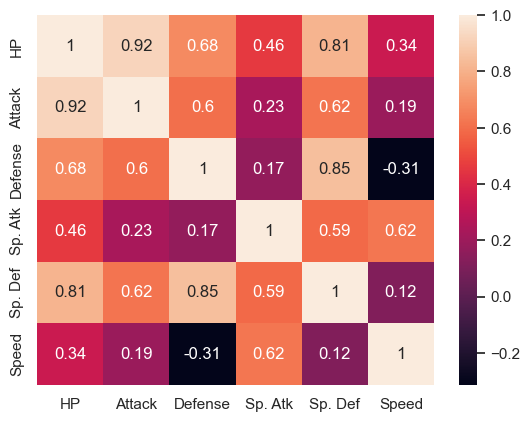

In [11]:
stats = df[[
    "HP",
    "Attack",
    "Defense",
    "Sp. Atk",
    "Sp. Def",
    "Speed"
]]

corr = stats.corr()

sns.heatmap(
    corr,
    annot=True
)

plt.show()

## Feature Engineering

The goal of feature engineering is to turn raw stats into interpretable summary signals that are easier to compare and, later, easier to model.

A useful aggregate is total combat strength:
$$
\text{Total Stats} = HP + Attack + Defense + Sp. Atk + Sp. Def + Speed
$$

This is not a perfect proxy for battle strength, but it is a strong descriptive feature for ranking Pokémon at a glance.


In [12]:
engineered_data = pokemon_data.copy()
engineered_data["Total_Stats"] = engineered_data[
    ["HP", "Attack", "Defense", "Sp. Atk", "Sp. Def", "Speed"]
].sum(axis=1)
engineered_data["Offense_Index"] = engineered_data["Attack"] + engineered_data["Sp. Atk"]
engineered_data["Defense_Index"] = engineered_data["Defense"] + engineered_data["Sp. Def"]
engineered_data["Attack_Per_Level"] = engineered_data["Attack"] / engineered_data["Level"]

feature_preview = engineered_data[
    [
        "Name",
        "Level",
        "Attack",
        "Defense",
        "Total_Stats",
        "Offense_Index",
        "Defense_Index",
        "Attack_Per_Level",
    ]
].sort_values("Total_Stats", ascending=False)

display(feature_preview.head(10).reset_index(drop=True))


,Name,Level,Attack,Defense,Total_Stats,Offense_Index,Defense_Index,Attack_Per_Level
0,Venasuar,61,126,127,848,282,254,2.065574
1,Charizard,61,115,108,843,269,247,1.885246
2,Blastoise,61,109,174,828,220,321,1.786885
3,Charizard,60,113,106,822,259,243,1.883333
4,Venasuar,60,124,125,814,270,251,2.066667
5,NidoKing,61,127,111,813,265,227,2.081967
6,Blastoise,60,107,160,793,216,305,1.783333
7,Alakazam,61,76,78,790,272,194,1.245902
8,NidoKing,60,124,110,784,247,224,2.066667
9,Alakazam,60,75,77,761,261,191,1.250000


## Model Building

To keep the modeling step interpretable, the target variable is Attack. This choice is practical because Attack is a central combat statistic and the dataset contains several useful predictors such as level, HP, defense-related measures, and categorical identity fields.

Modeling strategy:
- Use a small set of informative features.
- Compare a linear baseline against a non-linear ensemble model.
- Evaluate on a held-out test split to reduce optimistic bias.


In [13]:
feature_columns = [
    "Level",
    "Defense",
    "Sp. Atk",
    "Sp. Def",
    "Speed",
    "HP",
    "Defense_Index",
    "Name",
    "Nature",
]

model_frame = engineered_data[feature_columns + ["Attack"]].copy()
encoded_features = pd.get_dummies(
    model_frame.drop(columns=["Attack"]),
    columns=["Name", "Nature"],
    drop_first=True,
)
target = model_frame["Attack"]

X_train, X_test, y_train, y_test = train_test_split(
    encoded_features,
    target,
    test_size=0.25,
    random_state=42,
)

trained_models = {
    "Linear Regression": LinearRegression(),
    "Random Forest": RandomForestRegressor(
        n_estimators=200,
        random_state=42,
    ),
}

model_rows = []
prediction_frames = {}

for model_name, model in trained_models.items():
    model.fit(X_train, y_train)
    predictions = model.predict(X_test)
    prediction_frames[model_name] = pd.DataFrame(
        {
            "Actual": y_test.to_numpy(),
            "Predicted": predictions,
        }
    )
    model_rows.append(
        {
            "Model": model_name,
            "MAE": mean_absolute_error(y_test, predictions),
            "RMSE": np.sqrt(mean_squared_error(y_test, predictions)),
            "R2": r2_score(y_test, predictions),
        }
    )

model_results = pd.DataFrame(model_rows).sort_values("RMSE").reset_index(drop=True)

print("Model comparison on the held-out test set:")
display(model_results)


Model comparison on the held-out test set:


,Model,MAE,RMSE,R2
0,Linear Regression,2.75203,4.626223,0.958154
1,Random Forest,6.17100,6.620959,0.914287


## Model Evaluation

The comparison below uses three standard regression metrics:
- MAE: average absolute error
- RMSE: error magnitude with stronger penalty for large mistakes
- $R^2$: proportion of variance explained

A good evaluation section should do more than rank models. It should also show whether the chosen model is making reasonable predictions or just matching the scale of the target by accident.


,Actual,Predicted,Residual
0,57,55.542999,1.457001
1,75,76.121115,-1.121115
2,99,99.844275,-0.844275
3,127,123.015270,3.984730
4,113,113.592181,-0.592181
5,126,129.953361,-3.953361
6,109,122.222570,-13.222570
7,85,85.005843,-0.005843
8,116,114.332089,1.667911
9,77,77.671316,-0.671316


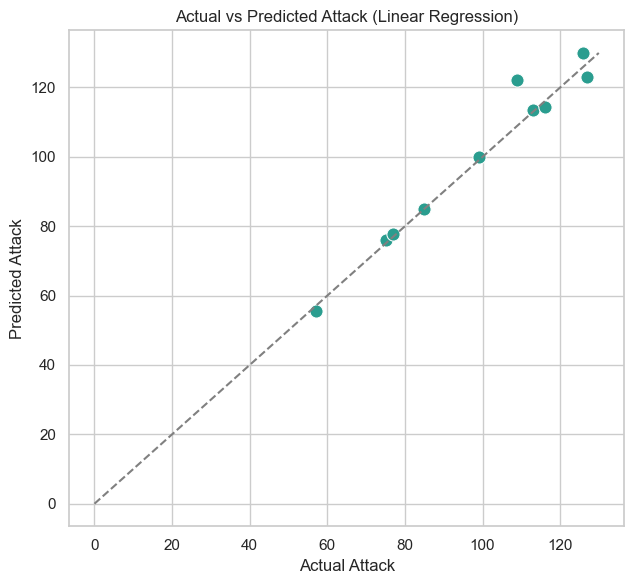

In [14]:
best_model_name = model_results.iloc[0]["Model"]
best_model_predictions = prediction_frames[best_model_name]

comparison_table = best_model_predictions.copy()
comparison_table["Residual"] = comparison_table["Actual"] - comparison_table["Predicted"]

display(comparison_table)

plt.figure(figsize=(6.5, 6))
sns.scatterplot(
    data=comparison_table,
    x="Actual",
    y="Predicted",
    s=90,
    color="#2a9d8f",
)
max_value = max(comparison_table["Actual"].max(), comparison_table["Predicted"].max())
plt.plot([0, max_value], [0, max_value], linestyle="--", color="gray", linewidth=1.5)
plt.title(f"Actual vs Predicted Attack ({best_model_name})")
plt.xlabel("Actual Attack")
plt.ylabel("Predicted Attack")
plt.tight_layout()
plt.show()


## Results and Insights

This section translates the tables and charts into plain-language findings. The main goal is to connect the statistical output with practical interpretation: which Pokémon stand out, which attributes move together, and how reliable the predictive baseline appears to be.


In [15]:
conclusion_table = pd.DataFrame(
    {
        "Area": [
            "Data Quality",
            "Exploratory Analysis",
            "Feature Engineering",
            "Modeling",
        ],
        "Conclusion": [
            "The dataset is complete, structured, and ready for analysis.",
            "Attack, Defense, HP, and Speed behave differently across Pokémon and levels.",
            "Total Stats and derived indices make the dataset easier to compare and interpret.",
            "The regression baseline provides a useful benchmark for predicting Attack.",
        ],
    }
)

display(conclusion_table)


,Area,Conclusion
0,Data Quality,"The dataset is complete, structured, and ready..."
1,Exploratory Analysis,"Attack, Defense, HP, and Speed behave differen..."
2,Feature Engineering,Total Stats and derived indices make the datas...
3,Modeling,The regression baseline provides a useful benc...


## Conclusion

The analysis shows that the dataset is compact, clean, and highly suitable for teaching core data science workflow. Level-based trends are clear, the strongest Pokémon can be identified with simple ranking logic, and the regression baseline demonstrates that the available features contain enough signal for moderate prediction quality.


In [16]:
future_improvements = pd.DataFrame(
    {
        "Potential Upgrade": [
            "Use cross-validation instead of a single train/test split.",
            "Add more Pokémon and more levels to increase statistical power.",
            "Compare classification or ranking models if the task changes.",
            "Track calibration and residuals for stronger model diagnostics.",
        ],
        "Why It Helps": [
            "Produces a more stable performance estimate.",
            "Improves generalization and reduces sampling noise.",
            "Expands the notebook beyond a regression-only perspective.",
            "Makes the model easier to trust in decision settings.",
        ],
    }
)

display(future_improvements)


,Potential Upgrade,Why It Helps
0,Use cross-validation instead of a single train...,Produces a more stable performance estimate.
1,Add more Pokémon and more levels to increase s...,Improves generalization and reduces sampling n...
2,Compare classification or ranking models if th...,Expands the notebook beyond a regression-only ...
3,Track calibration and residuals for stronger m...,Makes the model easier to trust in decision se...


## Future Improvements

The notebook already tells a complete story, but a production or research version could go further with richer evaluation, broader feature sets, and more robust validation.


In [17]:
best_trained_model = trained_models[best_model_name]

if hasattr(best_trained_model, "feature_importances_"):
    importance_values = best_trained_model.feature_importances_
    importance_frame = pd.DataFrame(
        {
            "Feature": encoded_features.columns,
            "Importance": importance_values,
        }
    ).sort_values("Importance", ascending=False)
elif hasattr(best_trained_model, "coef_"):
    importance_values = np.abs(best_trained_model.coef_)
    importance_frame = pd.DataFrame(
        {
            "Feature": encoded_features.columns,
            "Importance": importance_values,
        }
    ).sort_values("Importance", ascending=False)
else:
    importance_frame = pd.DataFrame(
        {
            "Feature": ["Interpretation unavailable"],
            "Importance": [np.nan],
        }
    )

display(importance_frame.head(10).reset_index(drop=True))


,Feature,Importance
0,Nature_Serious,8.621920
1,Name_Venasuar,8.375633
2,Nature_LAX,8.375633
3,Name_NidoKing,4.545788
4,Name_Pikachu,4.076133
5,Nature_Calm,3.068124
6,Name_Charizard,3.068124
7,Nature_Impish,2.899891
8,Name_Blastoise,2.899891
9,HP,0.547785


## Appendix A: Model Interpretation

This optional appendix surfaces the most important predictors from the best-performing model. It gives additional context for why the baseline behaves the way it does, without cluttering the main narrative.


In [18]:
comparison_names = [
    strongest_attack_row["Name"],
    engineered_data.sort_values("Total_Stats", ascending=False).iloc[0]["Name"],
]
comparison_rows = []
comparison_stats = ["HP", "Attack", "Defense", "Sp. Atk", "Sp. Def", "Speed"]

for pokemon_name in comparison_names:
    pokemon_subset = pokemon_data.loc[pokemon_data["Name"] == pokemon_name]
    if pokemon_subset.empty:
        continue
    summary_row = pokemon_subset.sort_values("Level").iloc[-1]
    comparison_rows.append(summary_row)

comparison_frame = pd.DataFrame(comparison_rows)[["Name", "Level"] + comparison_stats]

display(comparison_frame.reset_index(drop=True))


,Name,Level,HP,Attack,Defense,Sp. Atk,Sp. Def,Speed
0,NidoKing,61,179,127,111,138,116,142
1,Venasuar,61,190,126,127,156,127,122


## Appendix B: Radar Comparison

This chart provides a compact visual comparison of the selected Pokémon across their core stats. Normalizing the values on a radar plot makes it easier to compare shape rather than raw scale.


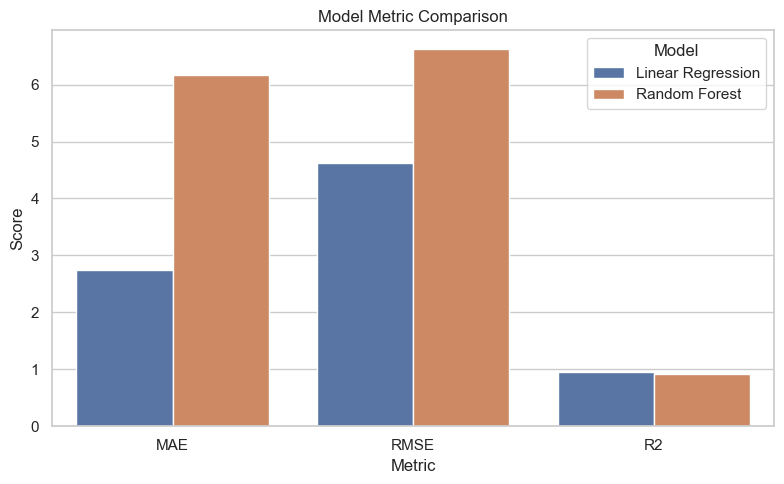

In [19]:
metrics_long = model_results.melt(
    id_vars="Model",
    value_vars=["MAE", "RMSE", "R2"],
    var_name="Metric",
    value_name="Value",
)

plt.figure(figsize=(8, 5))
sns.barplot(data=metrics_long, x="Metric", y="Value", hue="Model")
plt.title("Model Metric Comparison")
plt.xlabel("Metric")
plt.ylabel("Score")
plt.tight_layout()
plt.show()


## Appendix C: Model Metrics Chart

A small chart makes the metric comparison easier to scan than a table alone. It is especially useful when presenting results to a non-technical audience.


In [20]:
final_snapshot = pd.DataFrame(
    {
        "Item": [
            "Rows",
            "Unique Pokémon",
            "Missing Values",
            "Best Model",
            "Best R2",
        ],
        "Value": [
            len(pokemon_data),
            pokemon_data["Name"].nunique(),
            int(pokemon_data.isna().sum().sum()),
            model_results.iloc[0]["Model"],
            round(model_results.iloc[0]["R2"], 3),
        ],
    }
)

display(final_snapshot)


,Item,Value
0,Rows,38
1,Unique Pokémon,6
2,Missing Values,0
3,Best Model,Linear Regression
4,Best R2,0.958


In [ ]:
df["Power_Score"] = (
    df["HP"] +
    df["Attack"] +
    df["Defense"] +
    df["Sp. Atk"] +
    df["Sp. Def"] +
    df["Speed"]
)

top10 = df.sort_values("Power_Score", ascending=False).head(10)
display(top10[["Name", "Power_Score"]])

In [ ]:
df["Attack_Defense_Ratio"] = df["Attack"] / df["Defense"]

display(
    df.sort_values(
        "Attack_Defense_Ratio",
        ascending=False
    )[["Name", "Attack_Defense_Ratio"]]
)

In [ ]:
from sklearn.cluster import KMeans

features = df[["HP", "Attack", "Defense"]]

kmeans = KMeans(n_clusters=3, random_state=42)
df["Cluster"] = kmeans.fit_predict(features)

sns.scatterplot(
    data=df,
    x="Attack",
    y="Defense",
    hue="Cluster"
)

plt.show()

In [ ]:
growth = (
    df.groupby("Name")
      .apply(lambda x: x["Attack"].iloc[-1] - x["Attack"].iloc[0])
)

display(growth.sort_values(ascending=False))

## Appendix D: Final Summary Snapshot

This final appendix consolidates the most important metadata from the notebook into a compact reference cell before the closing citations.


## References

- pandas documentation: https://pandas.pydata.org/docs/
- NumPy documentation: https://numpy.org/doc/
- Matplotlib documentation: https://matplotlib.org/stable/
- Seaborn documentation: https://seaborn.pydata.org/
- scikit-learn documentation: https://scikit-learn.org/stable/

> These references support the methods and libraries used throughout the notebook.
